In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
import shap
from IPython.display import Markdown, display

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df = pd.read_csv(file_path)

# Data Cleaning
initial_shape = df.shape
df = df.drop_duplicates()
df = df.dropna()

print(f'Original dataset shape: {initial_shape}')
print(f'Dataset shape after cleaning: {df.shape}')
display(df.head())

Original dataset shape: (843, 26)
Dataset shape after cleaning: (816, 26)


,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [ ]:
physical_features = [
    'Have you noticed a rapid heartbeat or palpitations?',
    'Have you been dealing with anxiety or tension recently?',
    'Have you been dealing with anxiety or tension recently?.1',
    'Have you been getting headaches more often than usual?',
    'Do you face any sleep problems or difficulties falling asleep?',
    'Have you been experiencing any illness or health issues?',
    'Have you gained/lost weight?'
]

subjective_features = [
    'Have you recently experienced stress in your life?',
    'Do you get irritated easily?',
    'Do you have trouble concentrating on your academic tasks?',
    'Have you been feeling sadness or low mood?',
    'Do you often feel lonely or isolated?',
    'Do you feel overwhelmed with your academic workload?',
    'Are you in competition with your peers, and does it affect you?',
    'Do you find that your relationship often causes you stress?',
    'Are you facing any difficulties with your professors or instructors?',
    'Is your working environment unpleasant or stressful?',
    'Do you struggle to find time for relaxation and leisure activities?',
    'Is your hostel or home environment causing you difficulties?',
    'Do you lack confidence in your academic performance?',
    'Do you lack confidence in your choice of academic subjects?',
    'Academic and extracurricular activities conflicting for you?',
    'Do you attend classes regularly?'
]

all_features = physical_features + subjective_features

print([f for f in all_features if f not in df.columns])

[]


In [ ]:
df['y_binary'] = df['Which type of stress do you primarily experience?'].apply(
    lambda x: 0 if 'Distress' in str(x) and 'Eustress' not in str(x) else 1
)

counts = df['y_binary'].value_counts()
percentages = df['y_binary'].value_counts(normalize=True) * 100

display(pd.DataFrame({'Count': counts, 'Percentage (%)': percentages}))

,Count,Percentage (%)
y_binary,,
1,787,96.446078
0,29,3.553922


In [ ]:
from sklearn.preprocessing import MinMaxScaler

y = df['y_binary']
X_temp = df[all_features]

# Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_temp, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = MinMaxScaler()

X_all_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw[all_features]),
    columns=all_features
)
X_all_test = pd.DataFrame(
    scaler.transform(X_test_raw[all_features]),
    columns=all_features
)

# Split into Physical and Subjective sets
X_physical_train = X_all_train[physical_features]
X_physical_test  = X_all_test[physical_features]

X_subjective_train = X_all_train[subjective_features]
X_subjective_test  = X_all_test[subjective_features]

# Show shapes
print(f"X_all_train: {X_all_train.shape}")
print(f"X_all_test: {X_all_test.shape}")
print(f"X_physical_train: {X_physical_train.shape}")
print(f"X_physical_test: {X_physical_test.shape}")
print(f"X_subjective_train: {X_subjective_train.shape}")
print(f"X_subjective_test: {X_subjective_test.shape}")

X_all_train: (652, 23)
X_all_test: (164, 23)
X_physical_train: (652, 7)
X_physical_test: (164, 7)
X_subjective_train: (652, 16)
X_subjective_test: (164, 16)


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import pandas as pd

# Configure RFECV with Random Forest
cv = StratifiedKFold(n_splits=5)

rfecv_rf = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    step=1,
    cv=cv,
    scoring='f1_macro',
    min_features_to_select=1
)

# Fit the model
rfecv_rf.fit(X_all_train, y_train)

# 1. Show optimal number of features
print(f"Features otimas: {rfecv_rf.n_features_}")

# 2. List selected features
selected_rf = [f for f, s in zip(all_features, rfecv_rf.support_) if s]
print("\nSelected Features:")
print(selected_rf)

# 3. Create Ranking DataFrame
ranking_rf = pd.DataFrame({
    'Feature': all_features,
    'Ranking': rfecv_rf.ranking_,
    'Selected': rfecv_rf.support_,
    'Group': ['Physical' if f in physical_features else 'Subjective' for f in all_features]
}).sort_values('Ranking')

print("\nFeature Ranking Table:")
display(ranking_rf)

Features óptimas: 11

Selected Features:
['Have you noticed a rapid heartbeat or palpitations?', 'Have you been dealing with anxiety or tension recently?.1', 'Have you been experiencing any illness or health issues?', 'Have you gained/lost weight?', 'Do you get irritated easily?', 'Have you been feeling sadness or low mood?', 'Do you feel overwhelmed with your academic workload?', 'Are you in competition with your peers, and does it affect you?', 'Is your working environment unpleasant or stressful?', 'Is your hostel or home environment causing you difficulties?', 'Do you lack confidence in your academic performance?']

Feature Ranking Table:


,Feature,Ranking,Selected,Group
0,Have you noticed a rapid heartbeat or palpitat...,1,True,Physical
2,Have you been dealing with anxiety or tension ...,1,True,Physical
6,Have you gained/lost weight?,1,True,Physical
5,Have you been experiencing any illness or heal...,1,True,Physical
12,Do you feel overwhelmed with your academic wor...,1,True,Subjective
13,"Are you in competition with your peers, and do...",1,True,Subjective
10,Have you been feeling sadness or low mood?,1,True,Subjective
8,Do you get irritated easily?,1,True,Subjective
18,Is your hostel or home environment causing you...,1,True,Subjective
19,Do you lack confidence in your academic perfor...,1,True,Subjective


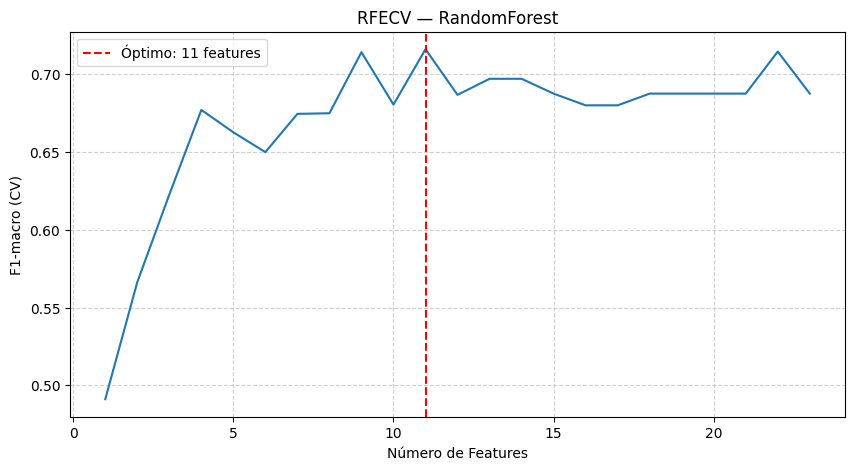

In [ ]:
# 4. Plot RFECV curve
plt.figure(figsize=(10,5))
plt.plot(range(1, len(rfecv_rf.cv_results_['mean_test_score']) + 1),
         rfecv_rf.cv_results_['mean_test_score'])
plt.xlabel('Número de Features')
plt.ylabel('F1-macro (CV)')
plt.title('RFECV — RandomForest')
plt.axvline(rfecv_rf.n_features_, color='red', linestyle='--',
            label=f'Óptimo: {rfecv_rf.n_features_} features')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, accuracy_score

experimentos = [
    ('RandomForest', 'All',        RandomForestClassifier(n_estimators=100, random_state=42), X_all_train,        X_all_test),
    ('RandomForest', 'Physical',   RandomForestClassifier(n_estimators=100, random_state=42), X_physical_train,   X_physical_test),
    ('RandomForest', 'Subjective', RandomForestClassifier(n_estimators=100, random_state=42), X_subjective_train, X_subjective_test),
    ('LogisticReg',  'All',        LogisticRegression(max_iter=1000, random_state=42),         X_all_train,        X_all_test),
    ('LogisticReg',  'Physical',   LogisticRegression(max_iter=1000, random_state=42),         X_physical_train,   X_physical_test),
    ('LogisticReg',  'Subjective', LogisticRegression(max_iter=1000, random_state=42),         X_subjective_train, X_subjective_test),
]

resultados = []
for nome, grupo, modelo, Xtr, Xte in experimentos:
    modelo.fit(Xtr, y_train)
    y_pred = modelo.predict(Xte)

    # Calculate metrics, handling potential cases where class 0 might not be predicted
    f1_scores = f1_score(y_test, y_pred, average=None)
    recall_scores = recall_score(y_test, y_pred, average=None)

    resultados.append({
        'Modelo': nome,
        'Features': grupo,
        'F1-macro': round(f1_score(y_test, y_pred, average='macro'), 3),
        'F1-Distress': round(f1_scores[0], 3),
        'Recall-Distress': round(recall_scores[0], 3),
        'Accuracy': round(accuracy_score(y_test, y_pred), 3)
    })

display(pd.DataFrame(resultados))

,Modelo,Features,F1-macro,F1-Distress,Recall-Distress,Accuracy
0,RandomForest,All,0.794,0.600,0.500,0.976
1,RandomForest,Physical,0.827,0.667,0.667,0.976
2,RandomForest,Subjective,0.744,0.500,0.333,0.976
3,LogisticReg,All,0.953,0.909,0.833,0.994
4,LogisticReg,Physical,0.600,0.222,0.167,0.957
5,LogisticReg,Subjective,0.744,0.500,0.333,0.976


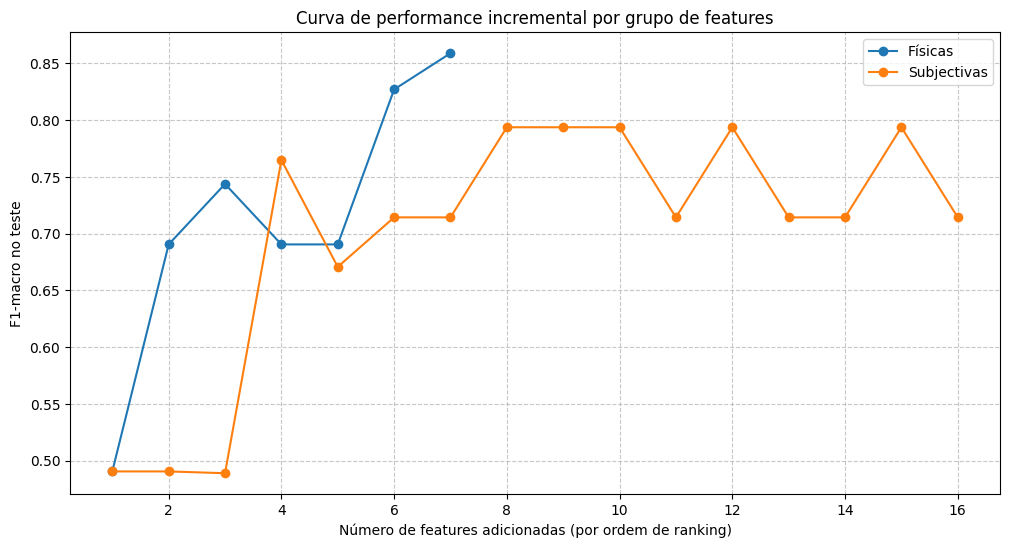

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

def curva_incremental(features_ordenadas, X_train, X_test, y_train, y_test, label):
    scores = []
    for i in range(1, len(features_ordenadas) + 1):
        feats = features_ordenadas[:i]
        m = RandomForestClassifier(n_estimators=100, random_state=42)
        m.fit(X_train[feats], y_train)
        y_pred = m.predict(X_test[feats])
        scores.append(f1_score(y_test, y_pred, average='macro'))
    plt.plot(range(1, len(scores) + 1), scores, marker='o', label=label)

# Prepare ordered lists based on RFECV ranking
physical_ordered = ranking_rf[ranking_rf['Group'] == 'Physical'].sort_values('Ranking')['Feature'].tolist()
subjective_ordered = ranking_rf[ranking_rf['Group'] == 'Subjective'].sort_values('Ranking')['Feature'].tolist()

# Plotting
plt.figure(figsize=(12, 6))
curva_incremental(physical_ordered, X_all_train, X_all_test, y_train, y_test, 'Físicas')
curva_incremental(subjective_ordered, X_all_train, X_all_test, y_train, y_test, 'Subjectivas')

plt.xlabel('Número de features adicionadas (por ordem de ranking)')
plt.ylabel('F1-macro no teste')
plt.title('Curva de performance incremental por grupo de features')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()